In [1]:
import pandas as pd 

In [2]:
df=pd.read_csv(r"C:\Users\ajayk\OneDrive\Desktop\online_food_delivery_dataset.csv")

# DATA EXPLORATION

In [3]:
df.head

<bound method NDFrame.head of      Order_ID  Order_Date       City Restaurant_Name Cuisine_Type  \
0        ORD1  2026-02-22     Mumbai       Spice Hub      Italian   
1        ORD2  2026-02-22       Pune   Curry Kingdom       Indian   
2        ORD3  2026-02-22  Hyderabad      Sushi Spot      Chinese   
3        ORD4  2026-02-22    Chennai      Sushi Spot      Italian   
4        ORD5  2026-02-22      Delhi     Burger Town       Indian   
...       ...         ...        ...             ...          ...   
1995  ORD1996  2026-02-22  Bangalore   Biryani House       Indian   
1996  ORD1997  2026-02-22      Delhi   Curry Kingdom    Fast Food   
1997  ORD1998  2026-02-22    Chennai     Burger Town      Italian   
1998  ORD1999  2026-02-22  Bangalore    Pizza Palace    Fast Food   
1999  ORD2000  2026-02-22      Delhi      Sushi Spot    Fast Food   

      Order_Amount Discount_Applied  Discount_Amount  Final_Amount  \
0           842.90              Yes              0.0        842.90   
1

In [4]:
df.head()

,Order_ID,Order_Date,City,Restaurant_Name,Cuisine_Type,Order_Amount,Discount_Applied,Discount_Amount,Final_Amount,Payment_Method,Delivery_Time_Minutes,Distance_km,Rider_Rating,Customer_Rating,Order_Status
0,ORD1,2026-02-22,Mumbai,Spice Hub,Italian,842.90,Yes,0.0,842.90,Card,107,6.32,4.4,3.8,Delivered
1,ORD2,2026-02-22,Pune,Curry Kingdom,Indian,974.79,Yes,50.0,924.79,UPI,101,2.68,4.7,3.8,Cancelled
2,ORD3,2026-02-22,Hyderabad,Sushi Spot,Chinese,1459.93,NaN,0.0,1459.93,Card,36,2.64,4.3,4.8,Cancelled
3,ORD4,2026-02-22,Chennai,Sushi Spot,Italian,151.44,Yes,100.0,51.44,Cash,74,6.32,3.3,3.6,Delivered
4,ORD5,2026-02-22,Delhi,Burger Town,Indian,949.10,Yes,0.0,949.10,Card,63,16.22,3.5,2.1,Delayed


In [5]:
df.info

<bound method DataFrame.info of      Order_ID  Order_Date       City Restaurant_Name Cuisine_Type  \
0        ORD1  2026-02-22     Mumbai       Spice Hub      Italian   
1        ORD2  2026-02-22       Pune   Curry Kingdom       Indian   
2        ORD3  2026-02-22  Hyderabad      Sushi Spot      Chinese   
3        ORD4  2026-02-22    Chennai      Sushi Spot      Italian   
4        ORD5  2026-02-22      Delhi     Burger Town       Indian   
...       ...         ...        ...             ...          ...   
1995  ORD1996  2026-02-22  Bangalore   Biryani House       Indian   
1996  ORD1997  2026-02-22      Delhi   Curry Kingdom    Fast Food   
1997  ORD1998  2026-02-22    Chennai     Burger Town      Italian   
1998  ORD1999  2026-02-22  Bangalore    Pizza Palace    Fast Food   
1999  ORD2000  2026-02-22      Delhi      Sushi Spot    Fast Food   

      Order_Amount Discount_Applied  Discount_Amount  Final_Amount  \
0           842.90              Yes              0.0        842.90   

In [6]:
df.describe()

,Order_Amount,Discount_Amount,Final_Amount,Delivery_Time_Minutes,Distance_km,Rider_Rating,Customer_Rating
count,2000.000000,1602.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1085.763850,73.501873,1026.888850,66.860000,15.840255,3.773350,3.495650
std,528.008753,55.899071,532.206049,30.612889,8.490122,0.712277,0.870899
min,150.350000,0.000000,13.000000,15.000000,1.000000,2.500000,2.000000
25%,630.217500,0.000000,572.170000,39.000000,8.337500,3.200000,2.700000
50%,1092.000000,50.000000,1029.485000,67.000000,16.035000,3.800000,3.500000
75%,1542.392500,100.000000,1487.135000,94.000000,23.400000,4.400000,4.200000
max,1999.160000,150.000000,1999.160000,119.000000,29.990000,5.000000,5.000000


# DATA CLEANING

# null values

In [7]:
df.isnull().sum()

Order_ID                   0
Order_Date                 0
City                       0
Restaurant_Name            0
Cuisine_Type               0
Order_Amount               0
Discount_Applied         692
Discount_Amount          398
Final_Amount               0
Payment_Method             0
Delivery_Time_Minutes      0
Distance_km                0
Rider_Rating               0
Customer_Rating            0
Order_Status               0
dtype: int64

In [8]:
df["Discount_Applied"]=df["Discount_Applied"].fillna(df["Discount_Applied"].mode()[0])

In [9]:
df.isnull().sum()

Order_ID                   0
Order_Date                 0
City                       0
Restaurant_Name            0
Cuisine_Type               0
Order_Amount               0
Discount_Applied           0
Discount_Amount          398
Final_Amount               0
Payment_Method             0
Delivery_Time_Minutes      0
Distance_km                0
Rider_Rating               0
Customer_Rating            0
Order_Status               0
dtype: int64

In [10]:
df["Discount_Amount"].skew()

np.float64(0.03352813227963141)

In [11]:
 df["Discount_Amount"]=df["Discount_Amount"].fillna(df["Discount_Amount"].mode()[0])

In [12]:
df.isnull().sum()

Order_ID                 0
Order_Date               0
City                     0
Restaurant_Name          0
Cuisine_Type             0
Order_Amount             0
Discount_Applied         0
Discount_Amount          0
Final_Amount             0
Payment_Method           0
Delivery_Time_Minutes    0
Distance_km              0
Rider_Rating             0
Customer_Rating          0
Order_Status             0
dtype: int64

In [13]:
print(df.duplicated().sum())

0


# OUTLINERS

In [14]:
import numpy as np
a=df.select_dtypes(include=np.number)

In [15]:
for i in a:
     q1=a[i].quantile(0.25)
     q2=a[i].quantile(0.50)
     q3=a[i].quantile(0.75)


In [16]:
IQR=q3-q1

In [17]:
Uw=q3+1.5*IQR
Lw=q1-1.5*IQR

In [18]:
outliners=((a[i]>Uw)&(a[i]<Lw))

In [19]:
print(outliners.sum())

0


# BOXPLOT

In [20]:
import seaborn as sns

<Axes: >

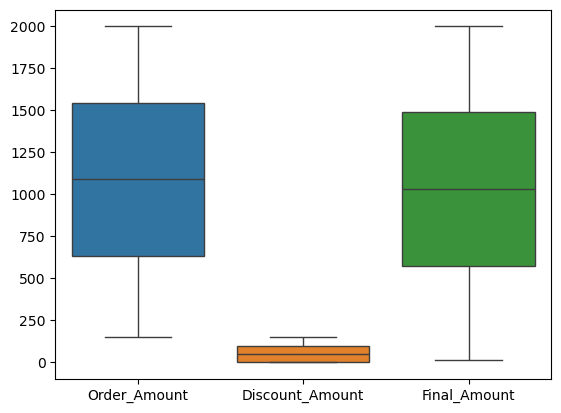

In [21]:
sns.boxplot([df['Order_Amount'],df['Discount_Amount'],df['Final_Amount']])

# DATA ANALYSIS

In [39]:
a=pd.DataFrame(df.groupby('City')['Order_ID'].count().sort_values(ascending=False))
a.to_csv('city order')

In [38]:
b=pd.DataFrame(df.groupby('Restaurant_Name')['Order_ID'].count().sort_values(ascending=False))
b.to_csv(' Restaurant name')

In [40]:
c=pd.DataFrame(df.groupby('Restaurant_Name')['Customer_Rating'].mean())
c.to_csv(' Restaurant rating')

In [42]:
d=pd.DataFrame(df.groupby('Cuisine_Type')['Order_ID'].count())
d.to_csv('food order')

In [43]:
e=pd.DataFrame(df.groupby('Order_Status')['Order_ID'].count())
e.to_csv('order status')

In [44]:
f=pd.DataFrame(df.groupby('Payment_Method')['Order_ID'].count())
f.to_csv('payment method')

In [45]:
import os 

In [46]:
os.getcwd()

'C:\\Users\\ajayk'